In [1]:
import sys
import numpy
import joblib
import skimage

print("Python:", sys.executable)
print("NumPy:", numpy.__version__)
print("NumPy path:", numpy.__file__)
print("joblib:", joblib.__file__)
print("skimage:", skimage.__file__)

Python: /home/pi/jupyter-env/bin/python3
NumPy: 1.23.5
NumPy path: /home/pi/.local/lib/python3.11/site-packages/numpy/__init__.py
joblib: /home/pi/.local/lib/python3.11/site-packages/joblib/__init__.py
skimage: /home/pi/jupyter-env/lib/python3.11/site-packages/skimage/__init__.py


In [2]:
import sys
!{sys.executable} -m pip install scikit-image
import hiwonder.ros_robot_controller_sdk as rrc
from hiwonder.Controller import Controller

board = rrc.Board()
ctl = Controller(board) 
import hiwonder.ActionGroupControl as AGC    #动作库，必须包含该库
import subprocess  

import numpy as np
from PIL import Image
import cv2
import time

from capture import capture_image
from identify import identify, Color, id_to_color, identify_color
import action


epsilon = 5
ARRIVE_THRESHOLD = 430  # 需要根据 identify.py 返回的 box 宽度实测校准


# 检查环境
import numpy
import scipy

print("numpy:")
print(numpy.__file__)
print(numpy.__version__)

print("scipy:")
print(scipy.__file__)
print(scipy.__version__)



Looking in indexes: https://pypi.org/simple, https://www.piwheels.org/simple
  Using cached numpy-2.4.6-cp311-cp311-manylinux_2_27_aarch64.manylinux_2_28_aarch64.whl (16.0 MB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_aarch64.manylinux2014_aarch64.whl (14.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Not uninstalling numpy at /home/pi/.local/lib/python3.11/site-packages, outside environment /home/pi/jupyter-env
    Can't uninstall 'numpy'. No files were found to uninstall.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.1.4 requires pytz>=2020.1, which is not installed.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
numpy:
/home/pi/.local/lib/python3.11/site-packages/numpy/__init__.py
1.23.5
scipy:
/home/pi/.local/lib/pytho

In [3]:
action.over_hurdle()

In [6]:
action.move_backward_one()

In [3]:
def go_to(id,COLOR_THRESHOLD, COLOR_LOST_THRESHOLD):  # 从某个点出发，走向名为id的点
    if id == 1:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.16
        COLOR_LOST_THRESHOLD = 0.1
    elif id == 2:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.05
        COLOR_LOST_THRESHOLD = 0.01
    elif id == 3:
        ARRIVE_THRESHOLD = 370
        COLOR_THRESHOLD = 0.05 
        COLOR_LOST_THRESHOLD = 0.015
    elif id == 4:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.14
        COLOR_LOST_THRESHOLD = 0.12
    elif id == 5:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.17
        COLOR_LOST_THRESHOLD = 0.1
    elif id == 6:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.002
        COLOR_LOST_THRESHOLD = 0.003
    elif id == 7:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.15
        COLOR_LOST_THRESHOLD = 0.1
    action.servo_look_forward()

    image = capture_image()

    proximity = turn_to(id, image)

    # =====================================================
    # 前进效率检测
    #
    # 未进入 arrived 阶段：
    # 如果一次前进后 proximity 的变化量 < 5，
    # 认为机器人前进没有明显接近目标。
    #
    # 此时后退一步，重新识别目标，
    # 再继续正常前进。
    # =====================================================

    previous_proximity = proximity

    # --------------------
    # 第一阶段：远距离导航
    # 大步前进
    # --------------------
    while proximity < ARRIVE_THRESHOLD:

        action.move_forward()

        image = capture_image()

        proximity = turn_to(id, image)

        # =================================================
        # 检测前进是否有效
        # =================================================

        proximity_change = abs(
            proximity - previous_proximity
        )

        print(
            f"Forward efficiency: "
            f"proximity {previous_proximity:.1f} -> "
            f"{proximity:.1f}, "
            f"change={proximity_change:.1f}"
        )

        if proximity_change < 5:

            print(
                "⚠️ Forward movement ineffective "
                "(proximity change < 5), "
                "moving backward one step."
            )

            action.move_backward_one()
            action.over_hurdle()

            # -------------------------------------------------
            # 后退之后必须重新识别
            #
            # 后退可能改变：
            # 1. 目标距离
            # 2. 目标偏角
            #
            # 所以不能直接继续使用旧 proximity。
            # 必须重新调用 turn_to()。
            # -------------------------------------------------

            image = capture_image()

            proximity = turn_to(id, image)

            print(
                f"After backward recovery: "
                f"proximity={proximity:.1f}"
            )

        # 更新上一帧 proximity
        previous_proximity = proximity

    # --------------------
    # 第二阶段：接近目标
    # 小步前进 + 颜色检测
    # --------------------
    arrived(
        id,
        COLOR_THRESHOLD,
        COLOR_LOST_THRESHOLD
    )

    return

BIG_TURN_THRESHOLD = 30   # 超过30°直接大转
epsilon = 8               # 小于8°认为已经对准


BIG_TURN_THRESHOLD = 30
epsilon = 8

# 初始估计：一次小转理论上约 3°
INITIAL_SMALL_TURN_ANGLE = 4

# 如果一批小转平均每次实际转动小于这个值，
# 说明当前地面摩擦较大，小转基本失效
MIN_EFFECTIVE_TURN = 0.5

# 实际小转角度的指数滑动平均系数
# 越大越相信最近一次测量
TURN_ESTIMATE_ALPHA = 0.3


def turn_to(id, image):
    """
    将机器人转向目标数字。

    自适应小转版本：

    1. 优先使用传入 image 进行第一次识别；
    2. 若第一次识别失败，则调用 search_target()；
    3. 偏航角 > BIG_TURN_THRESHOLD：
        执行一次大角度转动；
    4. 偏航角在 epsilon ~ BIG_TURN_THRESHOLD：
        根据当前估计的小转实际角度，
        计算本批需要执行多少次小转；
    5. 一批小转完成后重新识别；
    6. 根据：
            |转动前角度 - 转动后角度| / 小转次数
        计算这一批小转的实际平均效率；
    7. 使用指数滑动平均更新下一批小转角度；
    8. 如果实际平均小转角度 < 0.5°：
        认为当前地面摩擦导致小转失效，
        直接执行一次大转；
    9. 丢失目标后：
        调用 search_target() 重新寻找。
    """

    # 当前估计的一次小转实际角度
    small_turn_angle = INITIAL_SMALL_TURN_ANGLE

    # ---------------------------------
    # 第一次优先使用已经拍好的 image
    # ---------------------------------
    success, id_direction, proximity = identify(
        id,
        image
    )

    # 第一次识别失败才搜索
    if not success:

        id_direction, proximity = search_target(id)

    lost_count = 0

    while True:

        # =================================
        # 1. 已经对准
        # =================================
        if abs(id_direction) <= epsilon:

            print(
                f"Turn finished. "
                f"yaw={id_direction:.1f}°, "
                f"proximity={proximity}"
            )

            return proximity

        # =================================
        # 2. 大角度修正
        # =================================
        if abs(id_direction) > BIG_TURN_THRESHOLD:

            print(
                f"Large correction: "
                f"{id_direction:.1f} deg"
            )

            if id_direction > 0:
                action.turn_big_angle_left()
            else:
                action.turn_big_angle_right()

        # =================================
        # 3. 小角度修正
        # =================================
        else:

            # ---------------------------------
            # 根据当前估计的小转实际角度
            # 计算这一批需要转多少次
            # ---------------------------------
            turn_count = max(
                1,
                int(abs(id_direction) / small_turn_angle)
            )

            print(
                f"Small correction: "
                f"yaw={id_direction:.1f}°, "
                f"estimated turn="
                f"{small_turn_angle:.2f}°, "
                f"count={turn_count}"
            )

            # ---------------------------------
            # 记录这一批小转开始时的角度
            # ---------------------------------
            yaw_before = id_direction

            # ---------------------------------
            # 执行这一批小转
            # ---------------------------------
            for _ in range(turn_count):

                if id_direction > 0:
                    action.turn_small_angle_left()
                else:
                    action.turn_small_angle_right()

            # ---------------------------------
            # 给机器人一点时间稳定
            # ---------------------------------
            time.sleep(0.1)

            # ---------------------------------
            # 一批小转结束后重新识别
            # ---------------------------------
            image = capture_image()

            success, new_direction, proximity = identify(
                id,
                image
            )

            # ---------------------------------
            # 小转后目标丢失
            # ---------------------------------
            if not success:

                print(
                    f"Target {id} lost after "
                    f"{turn_count} small turns, "
                    f"searching directly..."
                )

                id_direction, proximity = search_target(id)

                lost_count = 0

            else:

                lost_count = 0

                # =================================
                # 计算这一批小转的实际平均效率
                # =================================

                actual_total_turn = abs(
                    yaw_before - new_direction
                )

                actual_turn_per_step = (
                    actual_total_turn / turn_count
                )

                print(
                    f"Small turn result: "
                    f"{yaw_before:.2f}° -> "
                    f"{new_direction:.2f}°"
                )

                print(
                    f"Actual total turn: "
                    f"{actual_total_turn:.2f}°"
                )

                print(
                    f"Actual turn per step: "
                    f"{actual_turn_per_step:.2f}°"
                )

                # =================================
                # 小于 0.5°
                #
                # 说明当前地面摩擦较大，
                # 小转基本没有效果
                # =================================
                if (
                    actual_turn_per_step
                    < MIN_EFFECTIVE_TURN
                ):

                    print(
                        f"Small turn ineffective: "
                        f"{actual_turn_per_step:.2f}° "
                        f"< {MIN_EFFECTIVE_TURN}°"
                    )

                    print(
                        "Switch to large turn."
                    )

                    # 根据重新识别到的方向决定大转方向
                    if new_direction > 0:
                        action.turn_big_angle_left()
                    else:
                        action.turn_big_angle_right()

                    time.sleep(0.1)

                    # 大转后立即重新识别
                    image = capture_image()

                    success, id_direction, proximity = identify(
                        id,
                        image
                    )

                    if success:
                        lost_count = 0

                    else:
                        lost_count += 1

                else:

                    # =================================
                    # 有效小转
                    #
                    # 使用指数滑动平均更新小转角度
                    # =================================
                    small_turn_angle = (
                        (1 - TURN_ESTIMATE_ALPHA)
                        * small_turn_angle
                        +
                        TURN_ESTIMATE_ALPHA
                        * actual_turn_per_step
                    )

                    print(
                        f"Updated small turn angle: "
                        f"{small_turn_angle:.2f}°"
                    )

                    # 更新方向
                    id_direction = new_direction

        # =================================
        # 4. 大转后重新识别
        #
        # 小转正常时这里也会再次确认状态
        # =================================
        time.sleep(0.1)

        image = capture_image()

        success, new_direction, proximity = identify(
            id,
            image
        )

        # ---------------------------------
        # 跟踪成功
        # ---------------------------------
        if success:

            id_direction = new_direction
            lost_count = 0

            continue

        # ---------------------------------
        # 跟踪失败
        # ---------------------------------
        lost_count += 1

        print(
            f"Target {id} lost "
            f"({lost_count}/3)"
        )

        # ---------------------------------
        # 连续丢失三次
        # → 重新搜索
        # ---------------------------------
        if lost_count >= 1:

            print(
                f"Searching target {id} again..."
            )

            id_direction, proximity = search_target(
                id
            )

            lost_count = 0
def search_target(id):
    """
    搜索目标数字。

    搜索策略：

    1. 当前姿态先拍摄并识别；
    2. 如果找到目标：
        将相机坐标系下的方向
        转换为机器人当前机身坐标系方向；
    3. 如果找不到：
        机器人向左执行一次大转；
    4. 最多执行 20 次大转；
    5. 仍然找不到则抛出异常。
    """

    for body_turn in range(20):

        # ---------------------------------
        # 当前姿态搜索
        # ---------------------------------
        action.servo_look_forward()
        image = capture_image()

        success, camera_direction, proximity = identify(
            id,
            image
        )

        if success:

            direction = (
                camera_direction
                + action.CURRENT_YAW
            )

            print(
                f"Found target {id}: "
                f"camera_yaw={camera_direction:.1f}°, "
                f"current_yaw={action.CURRENT_YAW:.1f}°, "
                f"direction={direction:.1f}°"
            )

            return direction, proximity
            
        action.servo_look_down()
        image = capture_image()

        success, camera_direction, proximity = identify(
            id,
            image
        )

        if success:

            direction = (
                camera_direction
                + action.CURRENT_YAW
            )

            print(
                f"Found target {id}: "
                f"camera_yaw={camera_direction:.1f}°, "
                f"current_yaw={action.CURRENT_YAW:.1f}°, "
                f"direction={direction:.1f}°"
            )

            return direction, proximity

        # ---------------------------------
        # 没找到
        # → 机器人向左转一次大角度
        # ---------------------------------
        print(
            f"Target {id} not found. "
            f"Robot turn left "
            f"({body_turn + 1}/20)"
        )

        action.turn_big_angle_left()

        time.sleep(0.5)

    raise RuntimeError(
        f"未找到目标数字{id}"
    )
    
def arrived(id, COLOR_THRESHOLD, COLOR_LOST_THRESHOLD):
    """
    最终到达判定。

    当前策略：

    1、机器人已经接近目标。

    2、云台切换到最低头。

    3、机器人继续缓慢前进。

    4、首先检测目标颜色。
       只有真正看到过目标颜色，
       seen_color 才会变成 True。

    5、颜色检测：

        ratio > COLOR_THRESHOLD
            → 明确看到颜色

        ratio < COLOR_LOST_THRESHOLD
            → 认为颜色真正消失

        中间区域
            → 不认为颜色消失

    6、已经看到颜色后：
       只要目标发生一次 temporary lost，
       就认为已经到达。

    7、最终定位阶段如果数字仍然能够识别，
       根据数字 yaw 进行小角度修正。

    8、小转角度不是固定值。
       根据一批小转前后的实际 yaw 变化，
       动态估计一次小转实际转过的角度。
       如果小转效率太低，则后退并跨过障碍

    9、如果已经看到颜色：
       单次最多执行3次小转。

    10、如果连续小步前进后，
        ratio 几乎没有变化，
        认为前进效率过低，
        后退一步进行恢复。

    11、后退之后必须重新进行颜色和数字检测，
        不能继续使用后退之前的旧数据。
    """

    color = id_to_color(id)

    action.servo_look_down()

    seen_color = False

    # =====================================================
    # 颜色 / 数字连续丢失计数
    # =====================================================

    target_lost_count = 0

    # =====================================================
    # 小转参数
    # =====================================================

    # 初始估计：一次小转约3°
    small_turn_angle = 3.0

    # 最小有效小转
    if id == 6:
        MIN_EFFECTIVE_TURN = 0
    else :
        MIN_EFFECTIVE_TURN = 0.5

    # 指数滑动平均系数
    TURN_ESTIMATE_ALPHA = 0.3

    # 已经看到颜色后，最多进行3次小转
    MAX_FINAL_TURNS = 3

    # =====================================================
    # 前进效率参数
    #
    # 一次小步前进后：
    # 如果 ratio 变化量 < MIN_RATIO_CHANGE（默认 0.002，id 6 为 0），
    # 认为当前位置变化太小。
    # =====================================================

    if id == 6 :
        MIN_RATIO_CHANGE = 0
    else :
        MIN_RATIO_CHANGE = 0.002

    previous_ratio = None
    last_move_was_forward = False

    while True:

        # =================================================
        # 1. 拍照
        # =================================================

        image = capture_image()

        # =================================================
        # 2. 颜色检测
        # =================================================

        ratio = identify_color(
            color,
            image
        )

        print(
            f"arrived ratio: "
            f"{ratio:.3f}, "
            f"seen_color={seen_color}, "
            f"lost_count={target_lost_count}"
        )

        # =================================================
        # 3. 颜色状态更新
        # =================================================

        if ratio > COLOR_THRESHOLD:

            seen_color = True

            # 只要颜色明确出现，
            # 就说明之前的“丢失”不能继续累计
            target_lost_count = 0

        # =================================================
        # 4. 已经看到颜色后，
        #    颜色真正消失
        # =================================================

        if (
            seen_color
            and ratio < COLOR_LOST_THRESHOLD
        ):

            target_lost_count += 1

            print(
                f"Target temporary lost "
                f"({target_lost_count}/1)"
            )

            # -------------------------------------------------
            # 当前策略：
            # seen_color == True 后，
            # 只要一次真正颜色丢失，
            # 就认为机器人已经到达。
            # -------------------------------------------------

            if target_lost_count >= 1:

                action.servo_look_forward()

                print(
                    f"arrived{id}: "
                    f"color lost after seeing target"
                )

                return True

        else:

            # ratio 位于两个阈值之间，
            # 不认为颜色真正消失。
            if ratio >= COLOR_LOST_THRESHOLD:

                target_lost_count = 0

        # =================================================
        # 5. 数字识别
        # =================================================

        success, yaw, proximity = identify(
            id,
            image
        )

        # =================================================
        # 6. 数字识别失败
        # =================================================

        if not success:

            print(
                f"Target {id} temporary lost."
            )

            # -------------------------------------------------
            # 即使数字丢失，
            # 仍然需要继续前进。
            #
            # 因为最终判定主要依赖：
            #
            #     看到颜色 → 颜色消失
            #
            # -------------------------------------------------
            if seen_color:

                print(
            f"arrived{id}: "
            f"target lost after seeing color."
        )

                action.servo_look_forward()

                return True
            # 数字丢失时直接小步前进，尝试重新接近目标。
            # 此处的 ratio 变化不能用于后退决策。

            action.move_forward_small()

            previous_ratio = ratio
            last_move_was_forward = True

            continue

        # =================================================
        # 7. 数字重新识别成功
        # =================================================

        print(
            f"Final yaw: {yaw:.1f}°, "
            f"proximity={proximity}"
        )

        # 数字重新出现
        target_lost_count = 0

        # =================================================
        # 8. 已经基本对准
        # =================================================

        if abs(yaw) <= epsilon:

            # -------------------------------------------------
            # 前进之前检查 ratio 变化。
            # -------------------------------------------------

            if previous_ratio is not None and last_move_was_forward:

                ratio_change = abs(
                    ratio - previous_ratio
                )

                print(
                    f"Forward efficiency: "
                    f"ratio {previous_ratio:.4f} -> "
                    f"{ratio:.4f}, "
                    f"change={ratio_change:.4f}"
                )

                if ratio_change < MIN_RATIO_CHANGE:

                    print(
                        "⚠️ Small forward movement ineffective "
                        "(ratio change < MIN_RATIO_CHANGE), "
                        "moving backward one step."
                    )

                    action.move_backward_one()
                    action.over_hurdle()

                    # -------------------------------------------------
                    # 后退之后重新计算方向。
                    # -------------------------------------------------

                    image = capture_image()

                    ratio = identify_color(
                        color,
                        image
                    )

                    success, yaw, proximity = identify(
                        id,
                        image
                    )

                    print(
                        f"After backward recovery: "
                        f"yaw={yaw if success else None}, "
                        f"ratio={ratio:.4f}, "
                        f"proximity={proximity if success else None}"
                    )

                    previous_ratio = ratio
                    last_move_was_forward = False

                    continue

            print(
                f"Target {id} already centered."
            )

            action.move_forward_small()

            previous_ratio = ratio
            last_move_was_forward = True

            continue

        # =================================================
        # 9. 根据当前实际估计的小转角，
        #    计算需要进行多少次小转
        # =================================================

        turn_count = max(
            1,
            int(abs(yaw) / small_turn_angle)
        )

        # =================================================
        # 10. 已经看到颜色
        #
        # 此时已经非常接近目标，
        # 最多允许3次小转。
        # =================================================

        if seen_color:

            turn_count = min(
                turn_count,
                MAX_FINAL_TURNS
            )

        print(
            f"Final correction: "
            f"yaw={yaw:.2f}°, "
            f"estimated_turn="
            f"{small_turn_angle:.2f}°, "
            f"count={turn_count}"
        )

        # =================================================
        # 11. 记录小转之前的yaw
        # =================================================

        yaw_before = yaw

        # =================================================
        # 12. 执行这一批小转
        # =================================================

        for _ in range(turn_count):

            if yaw > 0:

                action.turn_small_angle_left()

            else:

                action.turn_small_angle_right()

        # =================================================
        # 13. 小转后重新拍照
        # =================================================

        time.sleep(0.1)

        image = capture_image()

        # 小转之后重新计算颜色
        ratio = identify_color(
            color,
            image
        )

        success, new_yaw, new_proximity = identify(
            id,
            image
        )

        # =================================================
        # 14. 小转后目标丢失
        # =================================================

        if not success:

            print(
                f"Target {id} lost after "
                f"{turn_count} small turns."
            )

            # -------------------------------------------------
            # 注意：
            # 这里不能直接认为“前进效率低”。
            #
            # 因为刚刚执行的是转动，
            # ratio 的变化不能拿来评价前进效率。
            # -------------------------------------------------

            previous_ratio = ratio
            last_move_was_forward = True

            action.move_forward_small()

            continue

        # =================================================
        # 15. 计算实际小转效率
        # =================================================

        actual_total_turn = abs(
            yaw_before - new_yaw
        )

        actual_turn_per_step = (
            actual_total_turn / turn_count
        )

        print(
            f"Small turn result: "
            f"{yaw_before:.2f}° -> "
            f"{new_yaw:.2f}°"
        )

        print(
            f"Actual turn per step: "
            f"{actual_turn_per_step:.2f}°"
        )

        # =================================================
        # 16. 判断小转是否有效
        # =================================================

        if actual_turn_per_step >= MIN_EFFECTIVE_TURN:

            # =================================================
            # 使用指数滑动平均更新小转估计
            # =================================================

            small_turn_angle = (
                (1 - TURN_ESTIMATE_ALPHA)
                * small_turn_angle
                +
                TURN_ESTIMATE_ALPHA
                * actual_turn_per_step
            )

            print(
                f"Updated small turn angle: "
                f"{small_turn_angle:.2f}°"
            )

            last_move_was_forward = False

        else:

            print(
                f"Small turn ineffective: "
                f"{actual_turn_per_step:.2f}°"
            )

            # -------------------------------------------------
            # 小转效率过低：
            # 当前地面摩擦较大，小转基本失效。
            # 先向前小步移动，改变机器人与目标的相对位置，
            # 下一轮重新拍照、重新测量角度并继续小转修正。
            # -------------------------------------------------

            action.move_backward_one()
            action.over_hurdle()

            previous_ratio = ratio
            last_move_was_forward = False

            continue

        # =================================================
        # 17. 更新ratio
        #
        # 注意：
        # 这里发生的是转动，不是前进。
        # 因此只更新参考值，
        # 不用 ratio_change 判断前进效率。
        # =================================================

        previous_ratio = ratio

        # =================================================
        # 18. 小转之后不立即前进
        #
        # 下一轮重新拍照，
        # 重新判断：
        #
        #     yaw
        #     ratio
        #     seen_color
        #
        # 再决定前进还是继续修正。
        # =================================================

        continue

In [4]:
action.init_servo()
cur = 6
while(cur < 7):
    go_to(cur+1,0,0)
    cur += 1
    '''
if id == 1:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.16
        COLOR_LOST_THRESHOLD = 0.1
    elif id == 2:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.05
        COLOR_LOST_THRESHOLD = 0.01
    elif id == 3:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.05 
        COLOR_LOST_THRESHOLD = 0.015
    elif id == 4:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.18
        COLOR_LOST_THRESHOLD = 0.12
    elif id == 5:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.17
        COLOR_LOST_THRESHOLD = 0.1
    elif id == 6:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.01
        COLOR_LOST_THRESHOLD = 0.003
    elif id == 7:
        ARRIVE_THRESHOLD = 450
        COLOR_THRESHOLD = 0.17
        COLOR_LOST_THRESHOLD = 0.1
    '''

Target 7 not found. Robot turn left (1/10)
Target 7 not found. Robot turn left (2/10)
Target 7 not found. Robot turn left (3/10)
Target 7 not found. Robot turn left (4/10)
Target 7 not found. Robot turn left (5/10)
Found target 7: camera_yaw=14.6°, current_yaw=0.0°, direction=14.6°
Small correction: yaw=14.6°, estimated turn=4.00°, count=3
Small turn result: 14.58° -> 3.47°
Actual total turn: 11.11°
Actual turn per step: 3.70°
Updated small turn angle: 3.91°
Turn finished. yaw=3.4°, proximity=294
Turn finished. yaw=-0.2°, proximity=340
Forward efficiency: proximity 294.0 -> 340.0, change=46.0
Turn finished. yaw=0.4°, proximity=353
Forward efficiency: proximity 340.0 -> 353.0, change=13.0
Turn finished. yaw=-6.3°, proximity=378
Forward efficiency: proximity 353.0 -> 378.0, change=25.0
Small correction: yaw=-14.1°, estimated turn=4.00°, count=3
Small turn result: -14.09° -> -10.52°
Actual total turn: 3.56°
Actual turn per step: 1.19°
Updated small turn angle: 3.16°
Small correction: yaw=

In [4]:
# HSV 颜色标定辅助单元
# 运行前把目标颜色块放在机器人正前方，然后运行本单元。
# 它会低头拍照、打印画面中心 HSV 范围，并保存每个颜色的 mask 图片到 /tmp。


# 切换到颜色检测姿态（最低头）
action.servo_look_down()

image = capture_image()
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h, w = image.shape[:2]

# 画面中心区域（低头时色块大概在这里）的 HSV 统计
x1, y1 = int(w * 0.3), int(h * 0.4)
x2, y2 = int(w * 0.7), int(h * 0.8)
roi = hsv[y1:y2, x1:x2]
mean_hsv = np.mean(roi, axis=(0, 1))
min_hsv = np.min(roi, axis=(0, 1))
max_hsv = np.max(roi, axis=(0, 1))
print("=== 画面中心区域 HSV 统计（供标定参考） ===")
print(f"均值: H={mean_hsv[0]:.1f}, S={mean_hsv[1]:.1f}, V={mean_hsv[2]:.1f}")
print(f"最小: H={min_hsv[0]:.1f}, S={min_hsv[1]:.1f}, V={min_hsv[2]:.1f}")
print(f"最大: H={max_hsv[0]:.1f}, S={max_hsv[1]:.1f}, V={max_hsv[2]:.1f}")
print("提示：让色块充满中心区域后，根据上述范围修改 identify.py 里的 COLOR_RANGES。")

# 用当前 COLOR_RANGES 生成每种颜色的 mask 并保存可视化图片
print("=== 当前 COLOR_RANGES 检测效果 ===")
for color in Color:
    mask = np.zeros((h, w), dtype=np.uint8)
    for lower, upper in COLOR_RANGES.get(color, []):
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, lower, upper))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    ratio = cv2.countNonZero(mask) / (w * h)
    print(f"{color.name}: 当前画面占比={ratio:.3f}")
    vis = image.copy()
    vis[mask > 0] = [0, 255, 0]
    fname = f"/home/pi/Pictures/calibrate_{color.name}.jpg"
    cv2.imwrite(fname, vis)
    print(f"  已保存: {fname}")

print("标定方法：")
print("1. 查看 /tmp/calibrate_<颜色>.jpg，绿色区域就是被识别成该颜色的地方。")
print("2. 如果绿色把地面也标出来了，说明 HSV 范围太宽，需要收窄。")
print("3. 如果色块区域几乎没绿色，说明 HSV 范围太窄，需要放宽。")
print("4. 标定完成后，再运行 go_to() 测试到达逻辑。")


=== 画面中心区域 HSV 统计（供标定参考） ===
均值: H=79.6, S=91.7, V=162.8
最小: H=0.0, S=0.0, V=12.0
最大: H=179.0, S=255.0, V=198.0
提示：让色块充满中心区域后，根据上述范围修改 identify.py 里的 COLOR_RANGES。
=== 当前 COLOR_RANGES 检测效果 ===


NameError: name 'COLOR_RANGES' is not defined

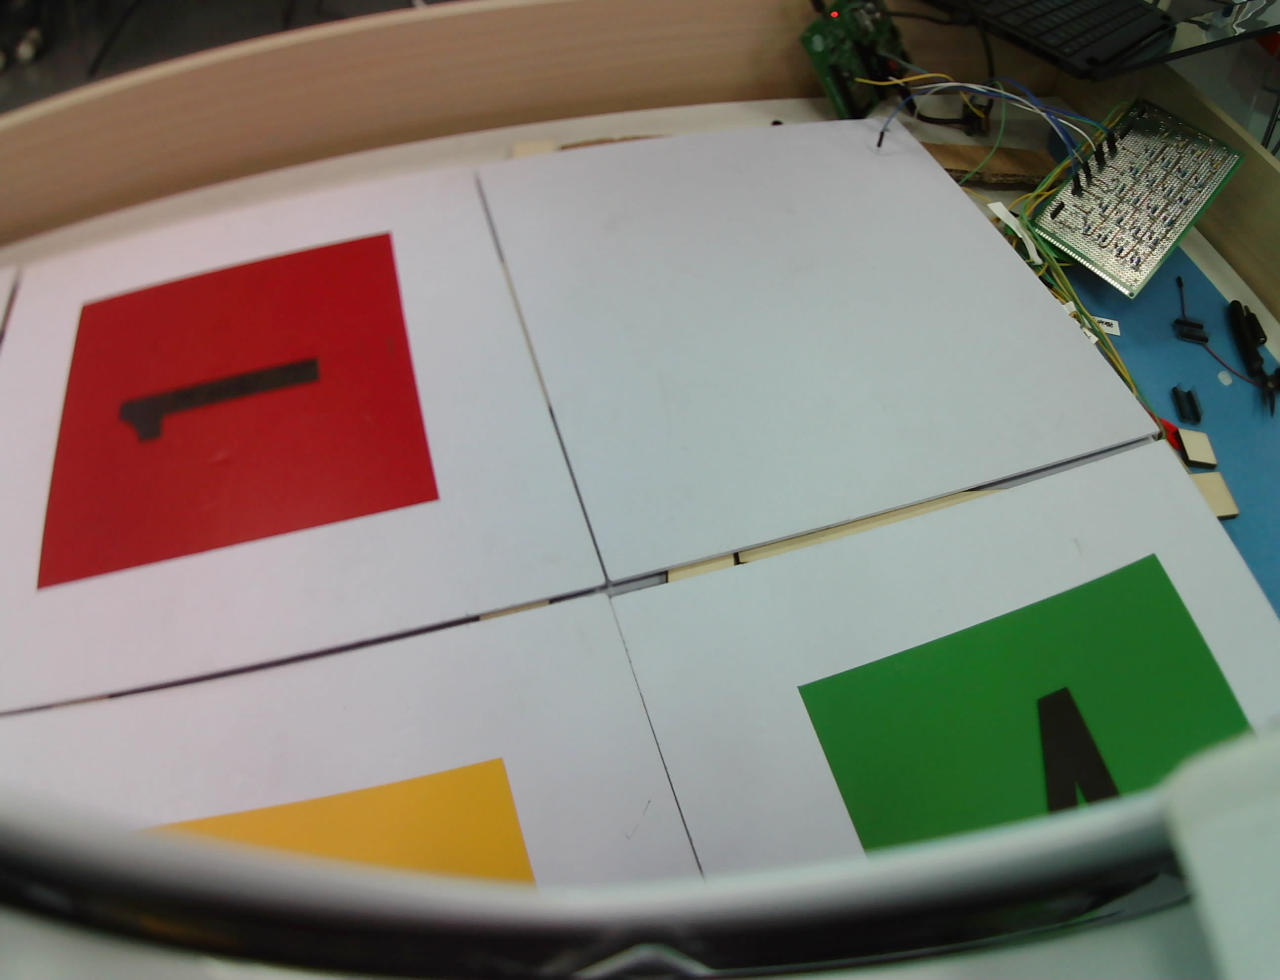

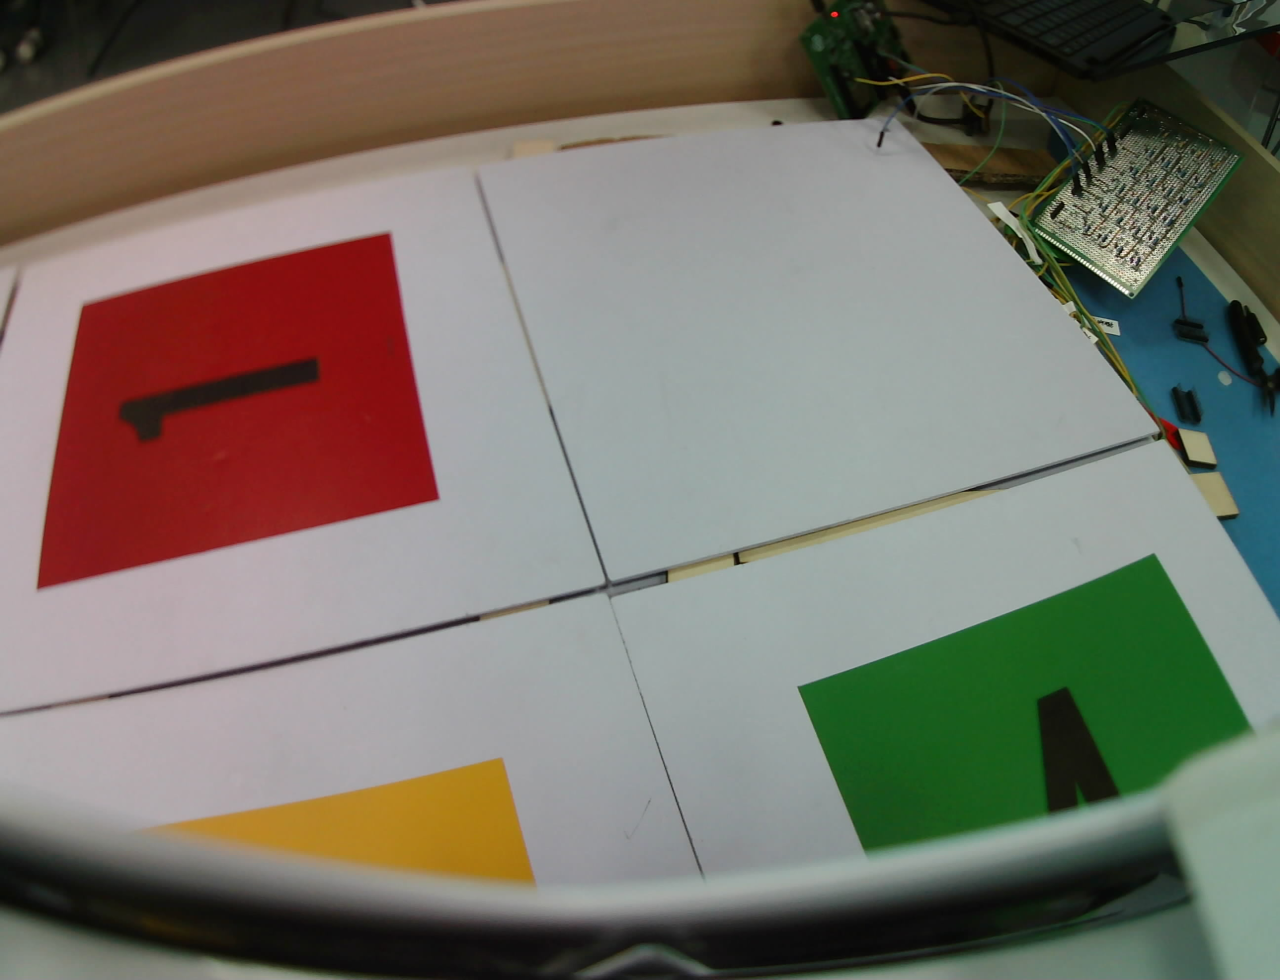

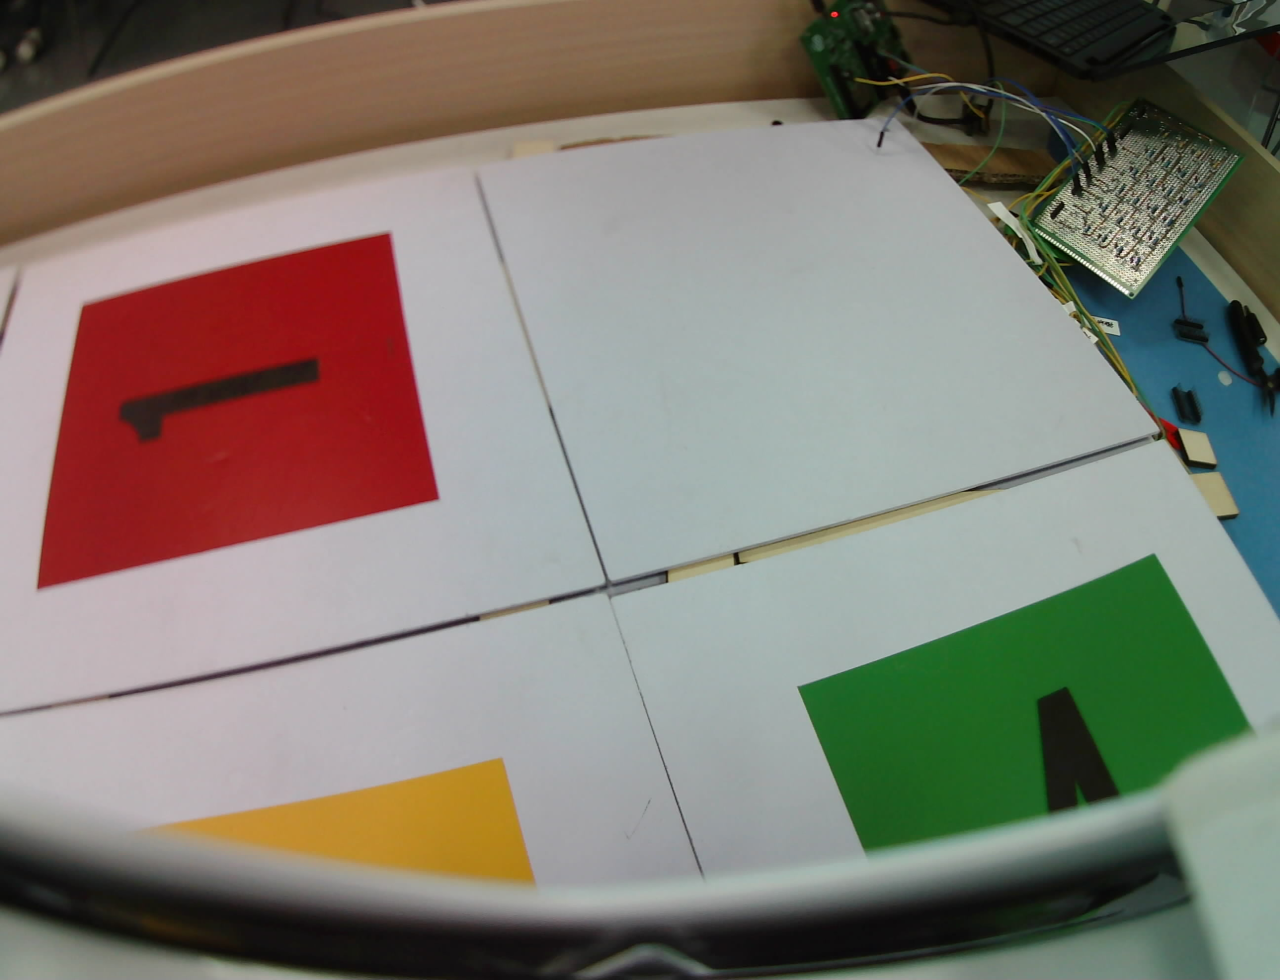

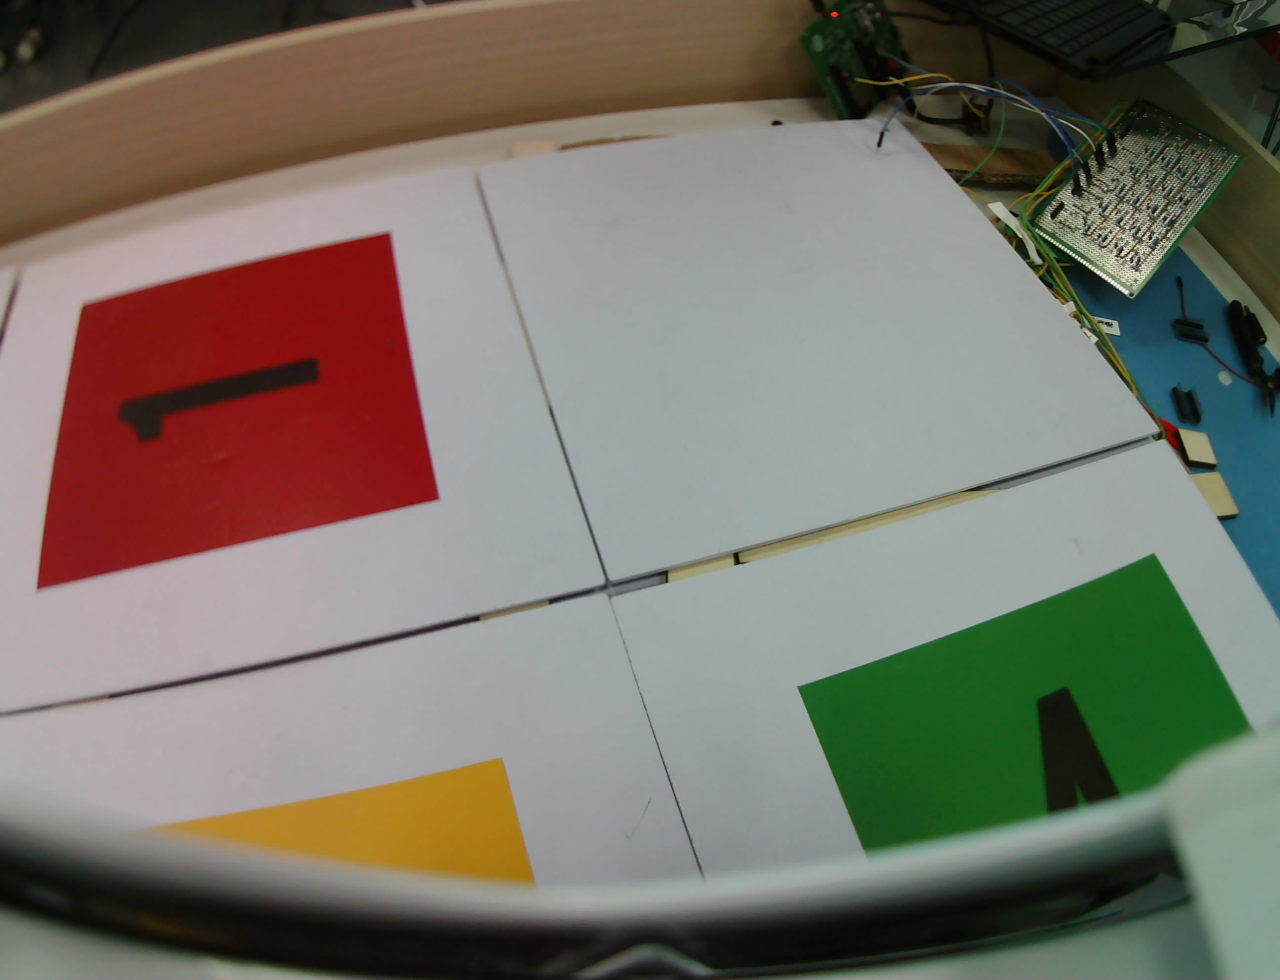

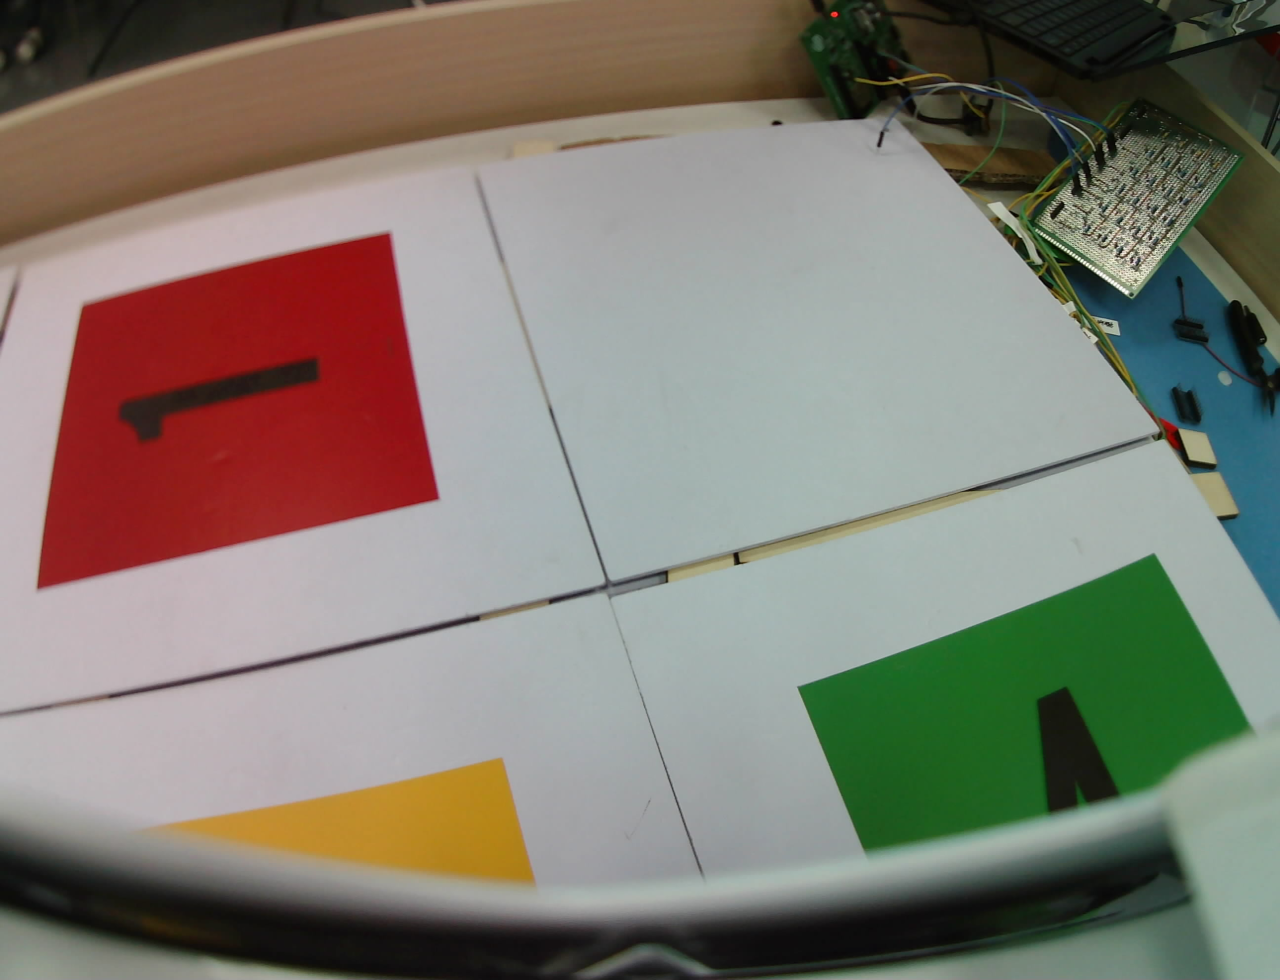

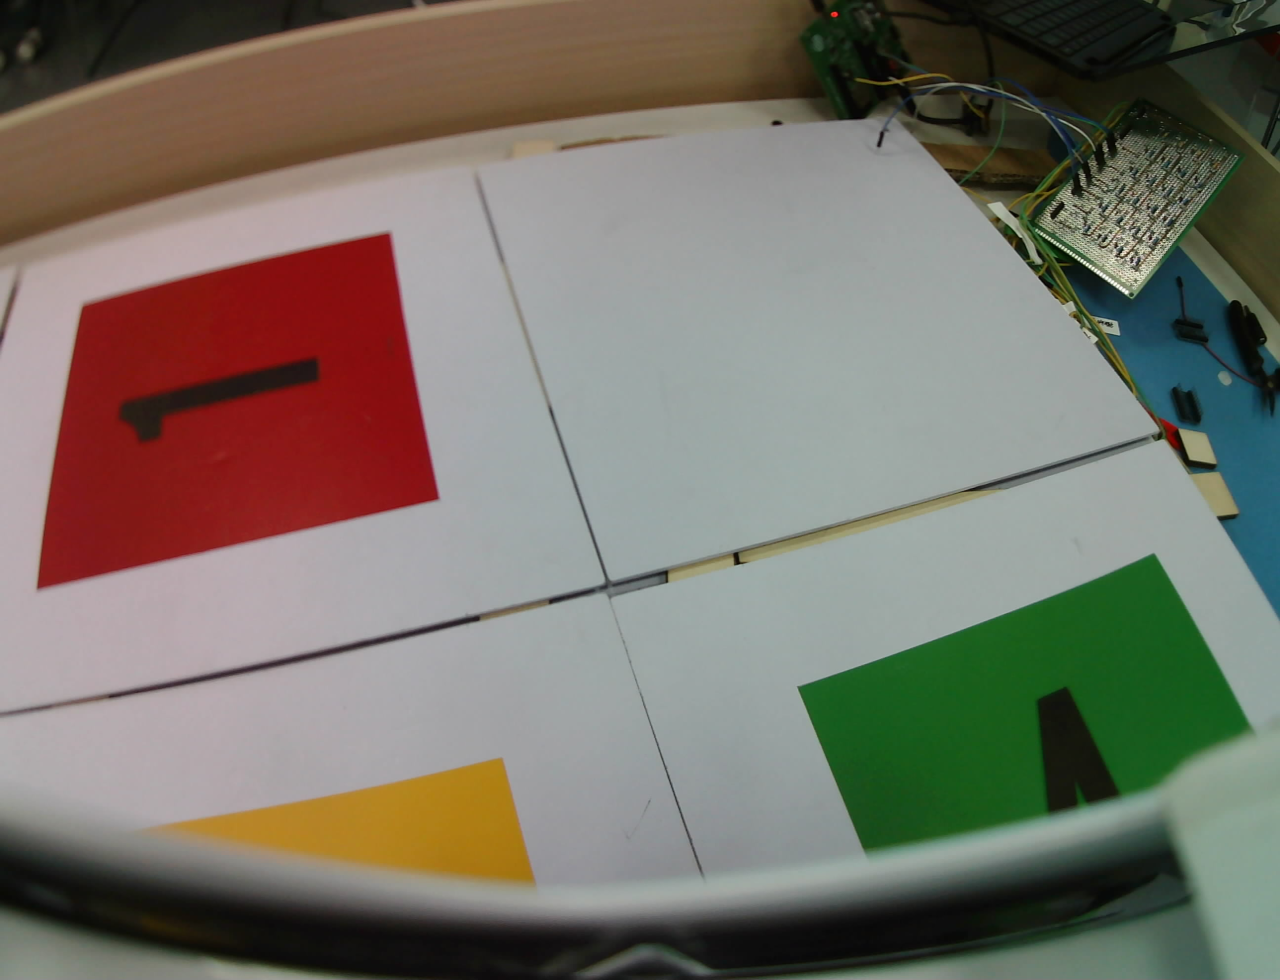

In [ ]:

import cv2
import numpy as np
import action
from capture import capture_image
from identify import Color, COLOR_RANGES


while True:
    image = capture_image()
    if image is not None:
    # BGR → RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 在 Jupyter 中直接显示
        display(Image.fromarray(image_rgb))
    else:
        print("拍照失败")

    time.sleep(1)
    

In [ ]:
ARRIVE_THRESHOLD = 450
COLOR_THRESHOLD = 0.17
COLOR_LOST_THRESHOLD = 0.12
go_to(1)

In [ ]:
COLOR_THRESHOLD = 0.05
COLOR_LOST_THRESHOLD = 0.01
go_to(2)

In [9]:
COLOR_THRESHOLD = 0.05
COLOR_LOST_THRESHOLD = 0.015
go_to(3)

✅ 照片已保存: /home/pi/Pictures/photo_1787542644.jpg
✅ 照片已保存: /home/pi/Pictures/photo_1787542645.jpg
Robot turn left and search again
✅ 照片已保存: /home/pi/Pictures/photo_1787542648.jpg
Robot turn left and search again
✅ 照片已保存: /home/pi/Pictures/photo_1787542652.jpg
Found target 3
Turn finished. yaw=-5.0°, proximity=470
✅ 照片已保存: /home/pi/Pictures/photo_1787542654.jpg
arrived ratio: 0.097, seen_color=False
Final yaw: -5.0°, proximity=471
✅ 照片已保存: /home/pi/Pictures/photo_1787542656.jpg
arrived ratio: 0.117, seen_color=True
Final yaw: -2.8°, proximity=517
✅ 照片已保存: /home/pi/Pictures/photo_1787542659.jpg
arrived ratio: 0.138, seen_color=True
Final yaw: -1.5°, proximity=555
✅ 照片已保存: /home/pi/Pictures/photo_1787542661.jpg
arrived ratio: 0.154, seen_color=True
Final yaw: -1.6°, proximity=526
✅ 照片已保存: /home/pi/Pictures/photo_1787542664.jpg
arrived ratio: 0.121, seen_color=True
Final yaw: -1.4°, proximity=510
✅ 照片已保存: /home/pi/Pictures/photo_1787542666.jpg
arrived ratio: 0.086, seen_color=True
Final yaw:

In [6]:
ARRIVE_THRESHOLD = 450
COLOR_THRESHOLD = 0.18
COLOR_LOST_THRESHOLD = 0.12
go_to(4)

✅ 照片已保存: /home/pi/Pictures/photo_1787542920.jpg
Small correction: 8.9 deg, turn 2 times
✅ 照片已保存: /home/pi/Pictures/photo_1787542925.jpg
Turn finished. yaw=-1.7°, proximity=419
✅ 照片已保存: /home/pi/Pictures/photo_1787542929.jpg
Turn finished. yaw=-0.4°, proximity=525
✅ 照片已保存: /home/pi/Pictures/photo_1787542930.jpg
arrived ratio: 0.138, seen_color=False
Final yaw: -0.4°, proximity=527
✅ 照片已保存: /home/pi/Pictures/photo_1787542933.jpg
arrived ratio: 0.132, seen_color=False
Final yaw: 1.1°, proximity=554
✅ 照片已保存: /home/pi/Pictures/photo_1787542935.jpg
arrived ratio: 0.153, seen_color=False
Final yaw: 3.8°, proximity=579
✅ 照片已保存: /home/pi/Pictures/photo_1787542938.jpg
arrived ratio: 0.208, seen_color=False
Final yaw: 7.5°, proximity=606
✅ 照片已保存: /home/pi/Pictures/photo_1787542940.jpg
arrived ratio: 0.203, seen_color=True
Final yaw: 8.6°, proximity=645
Final correction: 8.6 deg, turn 2 times
✅ 照片已保存: /home/pi/Pictures/photo_1787542945.jpg
arrived ratio: 0.206, seen_color=True
Final yaw: 4.8°, pro

In [6]:
ARRIVE_THRESHOLD = 450
COLOR_THRESHOLD = 0.17
COLOR_LOST_THRESHOLD = 0.1
go_to(5,0.17,0.1)

✅ 照片已保存: /home/pi/Pictures/photo_1787544759.jpg
Small correction: 21.8 deg, turn 7 times
✅ 照片已保存: /home/pi/Pictures/photo_1787544773.jpg
Turn finished. yaw=1.6°, proximity=490
✅ 照片已保存: /home/pi/Pictures/photo_1787544775.jpg
arrived ratio: 0.134, seen_color=False
Final yaw: 1.7°, proximity=492
✅ 照片已保存: /home/pi/Pictures/photo_1787544777.jpg
arrived ratio: 0.160, seen_color=False
Final yaw: 2.6°, proximity=527
✅ 照片已保存: /home/pi/Pictures/photo_1787544780.jpg
arrived ratio: 0.187, seen_color=False
Final yaw: 2.9°, proximity=549
✅ 照片已保存: /home/pi/Pictures/photo_1787544782.jpg
arrived ratio: 0.171, seen_color=True
Final yaw: 3.1°, proximity=563
✅ 照片已保存: /home/pi/Pictures/photo_1787544785.jpg
arrived ratio: 0.144, seen_color=True
Final yaw: 3.8°, proximity=559
✅ 照片已保存: /home/pi/Pictures/photo_1787544787.jpg
arrived ratio: 0.105, seen_color=True
Final yaw: 1.4°, proximity=390
✅ 照片已保存: /home/pi/Pictures/photo_1787544790.jpg
arrived ratio: 0.071, seen_color=True
arrived5


In [ ]:
go_to(6, 0.01,0.003)

In [7]:
go_to(7,0.15,0.09)

✅ 照片已保存: /home/pi/Pictures/photo_1787545318.jpg
Turn finished. yaw=2.4°, proximity=466
✅ 照片已保存: /home/pi/Pictures/photo_1787545320.jpg
arrived ratio: 0.114, seen_color=False
Final yaw: 2.5°, proximity=470
✅ 照片已保存: /home/pi/Pictures/photo_1787545322.jpg
arrived ratio: 0.131, seen_color=False
Final yaw: 6.7°, proximity=634
✅ 照片已保存: /home/pi/Pictures/photo_1787545325.jpg
arrived ratio: 0.158, seen_color=False
Final yaw: 7.3°, proximity=667
✅ 照片已保存: /home/pi/Pictures/photo_1787545327.jpg
arrived ratio: 0.166, seen_color=False
Final yaw: 7.3°, proximity=684
✅ 照片已保存: /home/pi/Pictures/photo_1787545330.jpg
arrived ratio: 0.193, seen_color=False
Final yaw: 7.1°, proximity=695
✅ 照片已保存: /home/pi/Pictures/photo_1787545333.jpg
arrived ratio: 0.186, seen_color=True
Final yaw: 7.8°, proximity=695
✅ 照片已保存: /home/pi/Pictures/photo_1787545335.jpg
arrived ratio: 0.137, seen_color=True
Final yaw: 8.3°, proximity=687
Final correction: 8.3 deg, turn 2 times
✅ 照片已保存: /home/pi/Pictures/photo_1787545340.jpg
a

In [ ]:
import os
import time
import cv2

import action

from capture import capture_image
from identify import identify, proximity_level
from candidate_classifier import classify_candidates


# 云台回正
action.servo_look_forward()

image = capture_image()

if image is None:

    print("拍照失败")

else:

    vis = image.copy()

    print("=== identify() 测试 ===")

    # 只跑一次分类
    results = classify_candidates(
        image,
        topk=10
    )

    print(
        f"candidate count: {len(results)}"
    )

    print()

    # 测试 identify()
    for test_id in range(1,8):

        success, yaw, proximity = identify(
            test_id,
            image,
            topk=10
        )

        msg = (
            f"数字 {test_id}: "
            f"success={success}"
        )

        if success:

            level = proximity_level(
                proximity
            )

            msg += (
                f", yaw={yaw:.2f}°"
                f", proximity={proximity}"
                f", level={level}"
            )

            # 去 classify_candidates 的结果里找框
            for r in results:

                if r["final_digit"] == test_id:

                    x,y,w,h = r["box"]

                    cv2.rectangle(
                        vis,
                        (x,y),
                        (x+w,y+h),
                        (0,255,0),
                        2
                    )

                    cv2.putText(

                        vis,

                        f"{test_id}",

                        (x,y-10),

                        cv2.FONT_HERSHEY_SIMPLEX,

                        1.0,

                        (0,255,0),

                        2

                    )

                    break

        print(msg)

    # --------------------------------
    # 保存结果
    # --------------------------------

    save_path = os.path.expanduser(

        f"~/Pictures/identify_test_"
        f"{int(time.time())}.jpg"

    )

    cv2.imwrite(
        save_path,
        vis
    )

    print()
    print(
        "可视化结果已保存:"
    )

    print(
        save_path
    )

In [8]:
# ============================================================
# 参数测定单元
# 用于测定 identify.py 和主逻辑中的关键参数
#
# 操作步骤：
# 1. 把目标数字牌放在摄像头正前方已知距离处。
# 2. 修改 TARGET_ID 为当前测试的数字。
# 3. 运行本单元，记录输出的 box width 和 yaw。
# 4. 分别在 25cm 和 50cm 处测试，得到 NEAR_THRESHOLD 和 MID_THRESHOLD。
# 5. 把目标放在画面左侧和右侧，确认 yaw 符号与机器人转向一致。
#    若不一致，修改 identify.py 中 calculate_yaw() 的符号。
# 6. CAMERA_FOV 优先查摄像头规格；若不知道，可用已知宽度物体标定。
# ============================================================

import os
import time
import cv2
import numpy as np
import action
from capture import capture_image
from identify import identify, proximity_level

# --------------------
# 修改这里为当前测试的数字
# --------------------
TARGET_ID = 5

# 可选：已知目标实际水平偏移角，用于校验 CAMERA_FOV
# 例如目标在摄像头正前方偏右 15 度，则填 15
KNOWN_REAL_ANGLE = None

action.servo_look_forward()
image = capture_image()

if image is None:
    raise RuntimeError("拍照失败")

h, w = image.shape[:2]
vis = image.copy()

success, yaw, proximity = identify(TARGET_ID, image, topk=5)

print("=== 参数测定结果 ===")
print(f"图片尺寸: {w}x{h}")
print(f"测试目标: {TARGET_ID}")
print(f"识别成功: {success}")

target_box = None

if success:
    level = proximity_level(proximity)
    print(f"yaw = {yaw:.2f}度  （当前约定：左侧为正，右侧为负）")
    print(f"box width = {proximity} px")

    # 从候选结果获取完整 box 信息
    _, _, candidates = identify(TARGET_ID, image, topk=5)
    for c in candidates:
        if c["model_digit"] == TARGET_ID:
            target_box = c["box"]
            break

    if target_box is not None:
        bx, by, bw, bh = target_box
        print(f"box = ({bx}, {by}, {bw}, {bh})")
        print(f"box height = {bh} px")
    else:
        print("box 信息获取失败")

    print(f"距离等级 = {level}")

    if KNOWN_REAL_ANGLE is not None:
        print("
已知真实角度 = ", KNOWN_REAL_ANGLE, "度")
        print(f"计算得到角度 = {yaw:.2f}度")
        ratio = KNOWN_REAL_ANGLE / yaw if yaw != 0 else 0
        print(f"比例 = {ratio:.3f}")
        print(f"建议 CAMERA_FOV = {60.0 * ratio:.1f}")

    # 在图上画框、中心线和标注
    if target_box is not None:
        x, y, bw, bh = target_box
        cx = x + bw // 2

        cv2.rectangle(vis, (x, y), (x+bw, y+bh), (0, 255, 0), 3)
        cv2.line(vis, (cx, y), (cx, y+bh), (0, 0, 255), 2)
        cv2.line(vis, (w//2, 0), (w//2, h), (255, 0, 0), 2)
        cv2.putText(
            vis,
            f"{TARGET_ID} w={bw}",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 255, 0),
            2,
        )
else:
    print("未识别到目标，请检查光线、位置和 candidate_classifier 加载。")

save_path = os.path.expanduser(
    f"~/Pictures/calibrate_id{TARGET_ID}_{int(time.time())}.jpg"
)
cv2.imwrite(save_path, vis)
print("标定图片已保存: ", save_path)
print("=== 标定建议 ===")
print("1. 25cm 处测试，记录 box width -> identify.py NEAR_THRESHOLD")
print("2. 50cm 处测试，记录 box width -> identify.py MID_THRESHOLD")
print("3. ARRIVE_THRESHOLD 建议等于 NEAR_THRESHOLD 或略小")
print("4. 左/右侧测试，若机器人转向与 yaw 符号相反，修改 calculate_yaw() 符号")
print("5. 摄像头 FOV 优先查规格；否则用已知宽度物体或已知角度标定 CAMERA_FOV")


SyntaxError: unterminated string literal (detected at line 72) (1457160382.py, line 72)